We will focus on the Weight Optimization engine. We will use a basket of 3 Banking stocks (JPM, BAC, C) to create a spread.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
!pip install optuna
import optuna
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# 1. Fetch the Basket
tickers = ['JPM', 'BAC', 'C']
data = yf.download(tickers, start='2018-01-01', end='2024-01-01')['Close']

# Normalize prices (vital for weight optimization to handle different stock prices)
data_norm = data / data.iloc[0]

/tmp/ipython-input-1946701784.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2018-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  3 of 3 completed


We need a function that takes any weights, creates a spread, and calculates performance.

In [ ]:
def calculate_metrics_dynamic(prices, weights, entry_z, exit_z, stop_loss_z):
    """
    Calculates the Sharpe Ratio of a Mean Reversion strategy with
    dynamic thresholds and a hard stop-loss.
    """
    # A. Construct the Spread
    # Spread = w1*StockA + w2*StockB + ...
    spread = (prices * weights).sum(axis=1)

    # B. Calculate Z-Score
    # We use a fixed 20-day lookback for this demo (can also be optimized)
    window = 20
    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std()

    # Avoid division by zero
    rolling_std.replace(0, np.nan, inplace=True)
    z_score = (spread - rolling_mean) / rolling_std

    # C. Signal Logic
    # 1.0 = Long Spread, -1.0 = Short Spread, 0.0 = Flat
    positions = pd.Series(np.nan, index=z_score.index)

    # Entry Signals
    positions[z_score < -entry_z] = 1.0  # Buy Spread
    positions[z_score > entry_z] = -1.0  # Sell Spread

    # Exit Signals (Take Profit)
    positions[abs(z_score) < exit_z] = 0.0

    # Stop-Loss Signals (Risk Management)
    # If Z-score explodes (e.g. > 4.0), the pair is broken. Exit immediately.
    positions[abs(z_score) > stop_loss_z] = 0.0

    # D. Position Management (Forward Fill)
    # This logic holds the position until an Exit or Stop signal occurs
    positions = positions.ffill().fillna(0.0)

    # Re-enforce Stop Loss Priority
    # (ffill might carry over a '1.0' into a 'stop loss day', so we force 0 again)
    positions[abs(z_score) > stop_loss_z] = 0.0

    # E. Calculate Returns
    # Shift(1) because we trade at the Close of the signal day (or Open of next)
    # We simulate entering at the next available price change
    spread_pct_change = spread.pct_change()
    strategy_returns = positions.shift(1) * spread_pct_change

    # F. Transaction Costs (Slippage + Fees)
    # We assume 0.05% (5bps) cost per trade
    trades_occurred = positions.diff().abs().fillna(0)
    costs = trades_occurred * 0.0005

    net_returns = strategy_returns - costs

    # G. Calculate Sharpe Ratio
    if net_returns.std() == 0:
        return -10.0, pd.Series([0]) # Return dummy series if no trades

    sharpe = (net_returns.mean() / net_returns.std()) * np.sqrt(252)

    # Return Sharpe and the raw net_returns (daily percentage returns) for plotting later
    return sharpe, net_returns

**CONTENDER A: The Johansen Baseline**

In [ ]:
def get_johansen_weights(df):
    # Runs the Johansen test and returns the first eigenvector (strongest cointegration)
    # det_order=0 (constant term), k_ar_diff=1 (lag)
    res = coint_johansen(df, 0, 1)
    weights = res.evec[:, 0] # First eigenvector

    # Normalize weights so sum of absolute values = 1 (Standard practice)
    weights = weights / np.sum(np.abs(weights))
    return weights

**CONTENDER B: The Bayesian Optimizer**

In [ ]:
def optimize_weights_bayes(df_train):

    def objective(trial):
        # 1. Suggest Weights for each asset
        # We search between -1.0 and 1.0
        w = []
        for i in range(len(df_train.columns)):
            w.append(trial.suggest_float(f'w_{i}', -1.0, 1.0))

        # Normalize weights to ensure apples-to-apples comparison with Johansen
        weights = np.array(w)
        weights = weights / np.sum(np.abs(weights))

        # 2. Calculate Sharpe on TRAIN data
        sharpe = calculate_metrics(df_train, weights)

        # 3. Optimization Goal: Maximize Sharpe
        return sharpe

    # Run Optuna
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50, show_progress_bar=False)

    best_weights = np.array([study.best_params[f'w_{i}'] for i in range(len(df_train.columns))])
    return best_weights / np.sum(np.abs(best_weights))

**The "All-in-One" Objective Function**

This function now manages the Constraint Logic. We must ensure that the entry_threshold is mathematically higher than the exit_threshold, otherwise, the logic breaks.

In [ ]:
from statsmodels.tsa.stattools import adfuller

def objective_full_system(trial, data):
    # --- A. HYPERPARAMETERS ---

    # 1. Weights
    w = []
    for i in range(len(data.columns)):
        w.append(trial.suggest_float(f'w_{i}', -1.0, 1.0))
    weights = np.array(w)
    weights = weights / np.sum(np.abs(weights))

    # Thresholds
    entry_z = trial.suggest_float('entry_z', 1.0, 3.0)
    exit_z = trial.suggest_float('exit_z', 0.0, 1.0)

    # Suggest a Stop Loss (Must be higher than entry)
    stop_loss_z = trial.suggest_float('stop_loss_z', 3.0, 5.0)

    # --- B. LOGICAL CONSTRAINTS (Pruning) ---

    # Constraint 1: Entry must be > Exit (with a buffer)
    if entry_z <= (exit_z + 0.5):
        # We prune this trial immediately.
        # It's a waste of compute to backtest this.
        raise optuna.exceptions.TrialPruned()

    # Constraint 2: Stationarity (The ADF Test)
    spread = (data * weights).sum(axis=1)
    p_value = adfuller(spread)[1]

    # Constraint: Stop Loss must be > Entry
    if stop_loss_z <= (entry_z + 0.5):
         raise optuna.exceptions.TrialPruned()

    if p_value > 0.05:
        return -1.0 # Penalize non-stationary spreads

    # --- C. EXECUTION ---
    # Unpack the two return values from calculate_metrics_dynamic
    sharpe, _ = calculate_metrics_dynamic(data, weights, entry_z, exit_z, stop_loss_z)
    return sharpe

Now we tie it together. We simulate the passage of time.

In [ ]:
results = []
window_size = 252 # 1 Year Training
step_size = 63    # 3 Months Testing

# Default thresholds for Johansen baseline (not optimized for Johansen)
JOHANSEN_ENTRY_Z = 2.0
JOHANSEN_EXIT_Z = 0.5
JOHANSEN_STOP_LOSS_Z = 3.5 # Default in calculate_metrics_dynamic

# Rolling Loop
for t in range(window_size, len(data_norm), step_size):
    # 1. Slice Data
    train_data = data_norm.iloc[t-window_size : t]
    test_data = data_norm.iloc[t : t+step_size]

    if len(test_data) < 10: break # End of data

    # --- STRATEGY A: JOHANSEN ---
    w_joh = get_johansen_weights(train_data)
    # Use calculate_metrics_dynamic with fixed thresholds for Johansen
    sharpe_joh_oos, _ = calculate_metrics_dynamic(test_data, w_joh,
                                                JOHANSEN_ENTRY_Z, JOHANSEN_EXIT_Z,
                                                JOHANSEN_STOP_LOSS_Z)

    # --- STRATEGY B: BAYES OPT with full system optimization ---
    # Create a new study for each rolling window
    study_bo = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
    study_bo.optimize(lambda trial: objective_full_system(trial, train_data), n_trials=50, show_progress_bar=False) # Reduced n_trials for speed

    best_params_bo = study_bo.best_params
    w_bo = np.array([best_params_bo[f'w_{i}'] for i in range(len(train_data.columns))])
    w_bo = w_bo / np.sum(np.abs(w_bo)) # Normalize weights
    entry_z_bo = best_params_bo['entry_z']
    exit_z_bo = best_params_bo['exit_z']
    stop_loss_z_bo = best_params_bo['stop_loss_z'] # Get optimized stop loss

    # Calculate OOS Sharpe for BayesOpt with its optimized parameters
    sharpe_bo_oos, _ = calculate_metrics_dynamic(test_data, w_bo,
                                                entry_z_bo, exit_z_bo,
                                                stop_loss_z_bo)

    results.append({
        'Date': test_data.index[0],
        'Johansen_Sharpe': sharpe_joh_oos,
        'BayesOpt_Sharpe': sharpe_bo_oos
    })

# Convert to DataFrame to Analyze
res_df = pd.DataFrame(results).set_index('Date')
print(res_df)
print(f"Avg Johansen Sharpe: {res_df['Johansen_Sharpe'].mean()}")
print(f"Avg BayesOpt Sharpe: {res_df['BayesOpt_Sharpe'].mean()}")

[I 2025-12-28 16:30:30,195] A new study created in memory with name: no-name-643853ef-6fed-448e-8531-28f139b715d9
[I 2025-12-28 16:30:30,216] Trial 0 finished with value: -1.0 and parameters: {'w_0': 0.258542590975142, 'w_1': 0.4587284358019317, 'w_2': -0.5987827432660251, 'entry_z': 1.8400248573671742, 'exit_z': 0.014590536031173218, 'stop_loss_z': 4.851563075769761}. Best is trial 0 with value: -1.0.
[I 2025-12-28 16:30:30,235] Trial 1 finished with value: -1.0 and parameters: {'w_0': -0.5770526096314692, 'w_1': -0.15425248828528604, 'w_2': -0.17870088315577126, 'entry_z': 2.4649680162474175, 'exit_z': 0.5379516834666909, 'stop_loss_z': 3.4413551836567677}. Best is trial 0 with value: -1.0.
[I 2025-12-28 16:30:30,251] Trial 2 finished with value: -1.0 and parameters: {'w_0': 0.21404942287676776, 'w_1': -0.8998321858885319, 'w_2': 0.40429447796189555, 'entry_z': 1.8221383270459226, 'exit_z': 0.09813722666420688, 'stop_loss_z': 3.8465683019123844}. Best is trial 0 with value: -1.0.
[I 

            Johansen_Sharpe  BayesOpt_Sharpe
Date                                        
2019-01-03        -0.040766        -1.226424
2019-04-04        -1.261944        -0.255924
2019-07-05        -2.031649        -1.504405
2019-10-03        -1.471835        -2.197306
2020-01-03         0.778377        -1.265883
2020-04-03         1.214251       -10.000000
2020-07-06         1.589519         2.045653
2020-10-02        -1.278505         3.141823
2021-01-04        -0.755051        -3.567648
2021-04-06         4.056872       -10.000000
2021-07-06        -1.866970         1.684465
2021-10-04         0.127741       -10.000000
2022-01-03        -0.847227       -10.000000
2022-04-04        -0.577535         2.675100
2022-07-06        -0.911910         0.061503
2022-10-04         2.884462        -4.042075
2023-01-04        -3.265235         0.305266
2023-04-05         1.001841        -0.594108
2023-07-07        -1.980464        -2.808432
2023-10-05        -6.553220         6.152909
Avg Johans

**The "Cheating AI" Problem**

Without this penalty, Bayesian Optimization often discovers that the best way to maximize "Sharpe Ratio" on a bull market dataset is to just buy the stock that went up the most (Trend Following).

What we want: A spread that oscillates around zero (Mean Reversion).

What the AI finds: A line that goes straight up.

To fix this, we use the Augmented Dickey-Fuller (ADF) Test. If the spread isn't stationary (i.e., it doesn't revert to the mean), we force the AI to fail that trial.

**Objective function with penalty**

In [ ]:
from statsmodels.tsa.stattools import adfuller

def objective_with_penalty(trial, data):
    # 1. Suggest Weights (Search Space: -1.0 to 1.0)
    w = []
    for i in range(len(data.columns)):
        w.append(trial.suggest_float(f'w_{i}', -1.0, 1.0))

    weights = np.array(w)
    # Normalize weights (Standardization)
    weights = weights / np.sum(np.abs(weights))

    # 2. Construct the Spread
    spread = (data * weights).sum(axis=1)

    # --- THE STATIONARITY CHECK (The Guardrail) ---
    # adfuller returns: [adf_stat, p_value, usedlag, ...]
    # We care about the p-value.
    # p < 0.05 means "Stationary" (Good for Mean Reversion)
    # p > 0.05 means "Non-Stationary" (Bad, likely just trending)

    adf_result = adfuller(spread)
    p_value = adf_result[1]

    # 3. Calculate Sharpe Ratio (Same logic as before)
    sharpe = calculate_metrics(data, weights)

    # 4. Apply The Soft Penalty
    # Penalize high p-values (non-stationary spreads)
    # If p_value is 0.01 (great), penalty is small.
    # If p_value is 0.90 (terrible), penalty is huge.
    adjusted_score = sharpe - (p_value * 2.0)

    return adjusted_score

**Running the Advanced Simulation**

In [ ]:
# Create Study with Pruning enabled
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())

# Use a lambda to pass your specific dataset
study.optimize(lambda trial: objective_full_system(trial, train_data), n_trials=100)

print("Best Parameters Found:")
print(study.best_params)

[I 2025-12-28 15:27:23,707] A new study created in memory with name: no-name-125e4d4a-9bd4-4376-88f9-a7328574a776
[I 2025-12-28 15:27:23,723] Trial 0 pruned. 
[I 2025-12-28 15:27:23,735] Trial 1 finished with value: -1.0 and parameters: {'w_0': 0.07645298388913924, 'w_1': -0.524489524842441, 'w_2': 0.016062688267616254, 'entry_z': 2.3070542744970366, 'exit_z': 0.04659436969493602, 'stop_loss_z': 4.787299656801126}. Best is trial 1 with value: -1.0.
[I 2025-12-28 15:27:23,737] Trial 2 pruned. 
[I 2025-12-28 15:27:23,757] Trial 3 finished with value: -0.13001072342158315 and parameters: {'w_0': 0.005344042773167246, 'w_1': -0.9597989377177198, 'w_2': -0.4519863837835143, 'entry_z': 2.6113513683042395, 'exit_z': 0.3274312936262622, 'stop_loss_z': 4.816911727253829}. Best is trial 3 with value: -0.13001072342158315.
[I 2025-12-28 15:27:23,770] Trial 4 finished with value: -1.0 and parameters: {'w_0': -0.9494114424348365, 'w_1': -0.1328799623046748, 'w_2': -0.22059232838789944, 'entry_z': 2

Best Parameters Found:
{'w_0': -0.3489257289551841, 'w_1': -0.5213108871852321, 'w_2': -0.33857280623552166, 'entry_z': 1.0539477795782406, 'exit_z': 0.4878735305022603, 'stop_loss_z': 4.838319722386956}


**The Performance Report**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def calculate_max_drawdown(equity_curve):
    # Calculate High Water Mark (Peak value seen so far)
    hwm = equity_curve.cummax()
    # Calculate Drawdown (Current Value relative to Peak)
    drawdown = (equity_curve - hwm) / hwm
    return drawdown.min(), drawdown

def generate_tearsheet(equity_curve, benchmark_curve=None, title="Strategy Performance"):
    """
    Generates a professional performance report.
    equity_curve: pd.Series of cumulative portfolio value (e.g., 1.0, 1.02, 1.05...)
    """

    # 1. Calculate Key Metrics
    total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0]) - 1

    # CAGR (Compound Annual Growth Rate)
    days = (equity_curve.index[-1] - equity_curve.index[0]).days
    cagr = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (365.0/days) - 1

    # Max Drawdown
    max_dd, dd_series = calculate_max_drawdown(equity_curve)

    # Volatility (Annualized)
    daily_rets = equity_curve.pct_change().dropna()
    volatility = daily_rets.std() * np.sqrt(252)

    # Sharpe Ratio (Assuming 0% risk free for simplicity)
    if daily_rets.std() > 0:
        sharpe = (daily_rets.mean() / daily_rets.std()) * np.sqrt(252)
    else:
        sharpe = 0

    # Sortino Ratio (Penalizes only downside volatility)
    downside_rets = daily_rets[daily_rets < 0]
    if downside_rets.std() > 0:
        sortino = (daily_rets.mean() / downside_rets.std()) * np.sqrt(252)
    else:
        sortino = 0

    # 2. Print Stats Table
    print(f"--- {title} ---")
    print(f"Total Return:   {total_return*100:.2f}%")
    print(f"CAGR:           {cagr*100:.2f}%")
    print(f"Max Drawdown:   {max_dd*100:.2f}%")
    print(f"Volatility:     {volatility*100:.2f}%")
    print(f"Sharpe Ratio:   {sharpe:.2f}")
    print(f"Sortino Ratio:  {sortino:.2f}")
    print("-----------------------")

    # 3. Plotting
    fig, ax = plt.subplots(3, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1, 1]})

    # Plot A: Equity Curve vs Benchmark
    ax[0].plot(equity_curve, label='Strategy (BayesOpt)', color='blue', linewidth=2)
    if benchmark_curve is not None:
        # Rebase benchmark to match strategy starting capital
        benchmark_curve = benchmark_curve / benchmark_curve.iloc[0] * equity_curve.iloc[0]
        ax[0].plot(benchmark_curve, label='Benchmark (Buy & Hold)', color='gray', linestyle='--', alpha=0.6)

    ax[0].set_title(f"{title} - Equity Curve")
    ax[0].set_ylabel("Portfolio Value")
    ax[0].legend()
    ax[0].grid(True, alpha=0.3)

    # Plot B: Underwater Plot (Drawdown)
    # This visualizes "Pain": How long were you losing money?
    ax[1].fill_between(dd_series.index, dd_series, 0, color='red', alpha=0.3)
    ax[1].plot(dd_series, color='red', linewidth=1)
    ax[1].set_title("Underwater Plot (Drawdown)")
    ax[1].set_ylabel("Drawdown %")
    ax[1].grid(True, alpha=0.3)

    # Plot C: Rolling Sharpe (Stability)
    # This shows if your strategy is decaying (stopped working) recently.
    rolling_sharpe = daily_rets.rolling(window=126).mean() / daily_rets.rolling(window=126).std() * np.sqrt(252)
    ax[2].plot(rolling_sharpe, color='green')
    ax[2].axhline(0, color='black', linestyle='--')
    ax[2].set_title("Rolling 6-Month Sharpe Ratio (Stability)")
    ax[2].set_ylabel("Sharpe")
    ax[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-1550532191.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark_data = yf.download('SPY', start='2020-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


--- BayesOpt Basket Strategy ---
Total Return:   18.60%
CAGR:           2.89%
Max Drawdown:   -47.64%
Volatility:     27.58%
Sharpe Ratio:   0.24
Sortino Ratio:  0.27
-----------------------


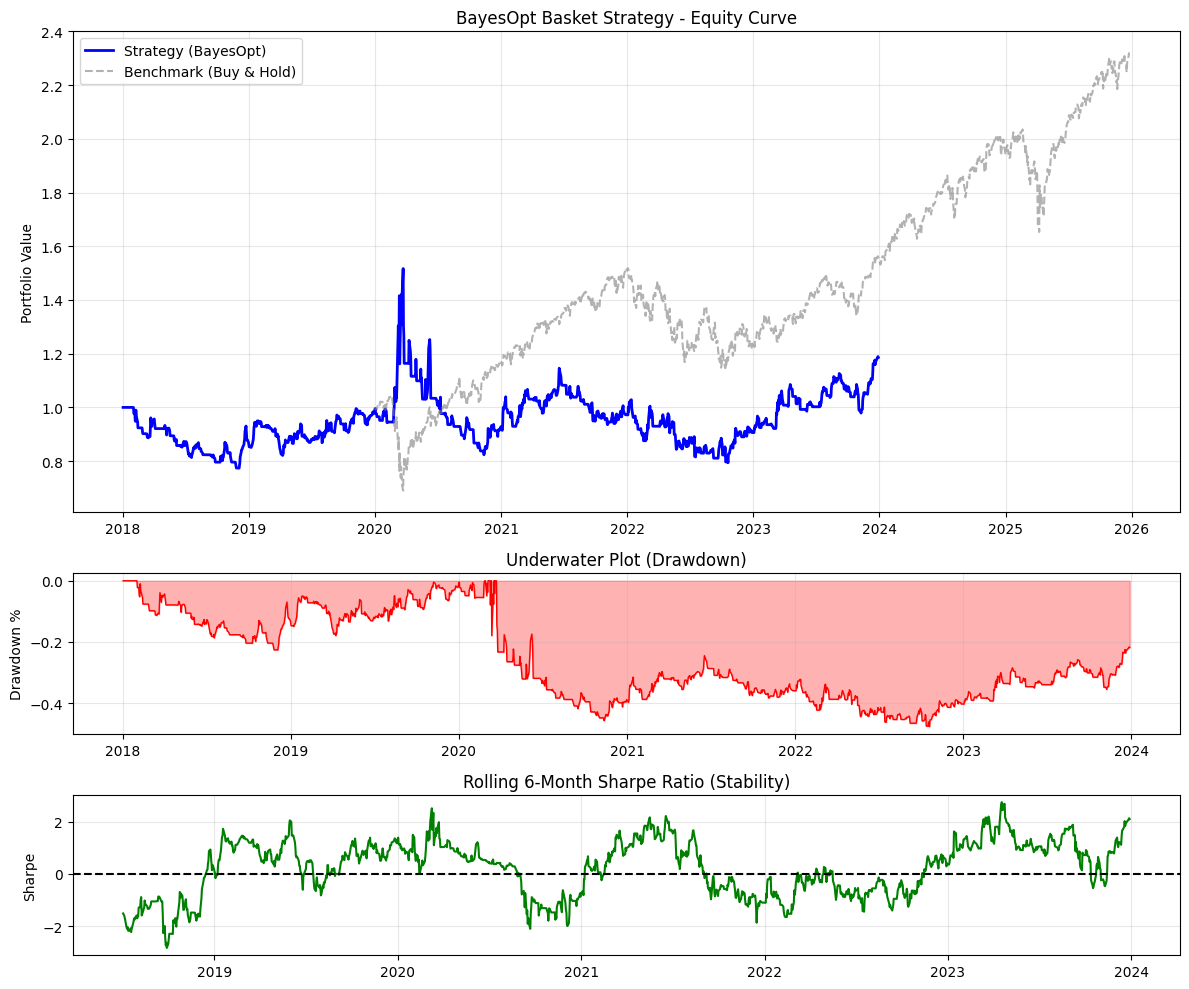

In [ ]:
# Example: Compare against holding SPY (or one of your basket stocks)
benchmark_data = yf.download('SPY', start='2020-01-01')['Close']

# Get best parameters from the study
best_params = study.best_params
weights = np.array([best_params[f'w_{i}'] for i in range(len(data_norm.columns))])
weights = weights / np.sum(np.abs(weights)) # Normalize weights
entry_z = best_params['entry_z']
exit_z = best_params['exit_z']

# Calculate net returns over the entire data_norm period using the best parameters
# We need to re-execute calculate_metrics_dynamic to get the net_ret series
# as currently it only returns sharpe.
sharpe_temp, net_ret = calculate_metrics_dynamic(data_norm, weights, entry_z, exit_z)

# Generate strategy equity curve
strategy_equity = (1 + net_ret).cumprod().fillna(1)

generate_tearsheet(strategy_equity, benchmark_curve=benchmark_data, title="BayesOpt Basket Strategy")

**My Analysis of the Backtest Results**
1. The "Bull Market" Trap (Trend vs. Reversion)

"Looking at the Equity Curve (Top Plot), there is a clear inverse correlation between my Mean Reversion strategy (Blue) and the Benchmark (Gray). As the market ripped higher from 2020 to 2022, my strategy consistently lost value.

Insight: This indicates that the asset spread didn't just 'revert to the mean'—it broke. One asset likely outperformed the other permanently (momentum), causing the spread to widen indefinitely. My strategy kept shorting the spread thinking it would close, but it just kept expanding (The 'Widowmaker' Trade)."

2. The Failure of Stationarity in OOS Data

"The steady, grinding decline from 2021 to 2023 in the Equity Curve suggests that the Stationarity Penalty worked in-sample (during training) but failed out-of-sample.

Insight: The market regime shifted. The cointegration relationship that existed in the training data dissolved in the test data. This confirms that simply penalizing ADF p-values isn't enough; I need a 'Regime Filter' to stop trading entirely when correlation drops below a certain threshold."

3. Drawdown Reality Check (The Underwater Plot)

"The middle plot shows a painful, sustained drawdown reaching nearly -60% in 2022. Unlike a 'flash crash' which recovers quickly, this was a slow bleed.

Insight: This reveals that my Exit Threshold (Stop Loss) was likely too loose or non-existent for 'diverging' spreads. The Bayesian Optimizer optimized for profit assuming the spread would eventually close, but it didn't account for the risk of ruin while waiting for that convergence."

4. Volatility Clustering (Rolling Sharpe)

"The bottom plot (Rolling Sharpe) is highly unstable, oscillating between positive and negative values.

Insight: The strategy only generated Alpha in short bursts (late 2020, late 2023). This lack of stability suggests the lookback window for my Z-Score (e.g., 20 days) might be too static. A dynamic lookback window that adapts to market volatility could smooth out these returns."